## Star viewer notebook

Hello! This is the tool that lets you view stars. Everything is included here, you can use functions draw(n) to view a partial drawing featuring the star, and describe(n) to see what are the recorded quantities that are non-zero, or inspect(n) for both.

## Section 0: setup 

In [2]:
STAR_SHEET_PATH = "../include4/star_data.csv"

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

# ---------- Geometry Stuff  ----------
def regular_pentagon_points(center=(0, 0), radius=1, rotation=-90):
    """Return 5 vertices (x, y) of a regular pentagon"""
    cx, cy = center
    angles = np.linspace(0, 2 * np.pi, 6)[:-1] + np.deg2rad(rotation)
    return np.array([
        (cx + radius * np.cos(a), cy + radius * np.sin(a))
        for a in angles
    ])

def line_from_points(p1, p2):
    """Return (A, B, C) for line Ax + By = C having p1 and p2 in its interior"""
    A = p2[1] - p1[1]
    B = p1[0] - p2[0]
    C = A * p1[0] + B * p1[1]
    return A, B, C

def line_intersection(L1, L2):
    """Find intersection (x,y) of two lines given by (Ai, Bi, Ci)."""
    A1, B1, C1 = L1
    A2, B2, C2 = L2
    det = A1 * B2 - A2 * B1
    if abs(det) < 1e-9:
        return None
    x = (B2 * C1 - B1 * C2) / det
    y = (A1 * C2 - A2 * C1) / det
    return np.array([x, y])

# ---------- Drawing stuff ----------
def continuation_triangle_for_side(pts, i):
    """
    Given pentagon vertices pts[0..4],
    return the base pts A,B and the tip of the triangle attached to side i.
    """
    n = len(pts)  # 5 but like this it will be useable for other regular polygons as well
    A = pts[i]
    B = pts[(i + 1) % n]
    left_prev = pts[(i - 1) % n]
    right_next = pts[(i + 2) % n]

    # Neighboring sides (extended outward)
    L_left = line_from_points(left_prev, A)
    L_right = line_from_points(B, right_next)

    tip = line_intersection(L_left, L_right)
    return A, B, tip

def draw_config(ax, pts, i, config):
    """
    Draw triangle on side i with customizable tip, color, and cross-lines.

    Parameters
    ----------
    ax : matplotlib axis
        needed for drawing
    pts : ndarray
        pentagon vertices
    i : int
        index of the side (0-4)
    config : dict
        Configuration for this side, e.g.:
        {
            "tip": "vertex" | "crossing" | "plain" | "extend_face" | "extend_face_bisect",
                        #---- vertex, crossing, or nothing at triangle tip, or other pentagons
            "color": "red",                             # color
            "tip_size": 1,                              # for 'vertex'
            "extend_ratio": 0.5,                        # for 'crossing'
            "alpha": 0.4,                               # fill alpha
            "cross_lines": 0 | 1 | 2,                   # how many lines to draw parallel to base
            "cross_alpha": 0.6,                         # transparency for cross lines
            "cross_lw": 1.5                             # line width for cross lines
        }
    """
    from matplotlib.patches import Polygon, Circle

    # calculate triangle
    A, B, T = continuation_triangle_for_side(pts, i)

    # get config stuff 
    tip_type = config.get("tip", "plain")
    color = config.get("color", "orange")
    alpha = config.get("alpha", 0.4)
    tip_size = config.get("tip_size", 1)
    extend_ratio = config.get("extend_ratio", 0.5)
    cross_lines = config.get("cross_lines", 0)
    cross_alpha = config.get("cross_alpha", 0.6)
    cross_lw = config.get("cross_lw", 1.5)

    # Draw base triangle shape or outline 
    if tip_type == "plain":
        tri = Polygon([A, B, T], closed=True, color=color, alpha=alpha)
        ax.add_patch(tri)

    elif tip_type == "vertex":
        tri = Polygon([A, B, T], 
                        closed=True, 
                        edgecolor=color,
                        facecolor='none', 
                        lw=2
                    )
        ax.add_patch(tri)
        ax.add_patch(Circle(T, radius=tip_size, color=color, alpha=0.7))

    elif tip_type == "crossing":
        # Draw extended side lines past the tip
        v1 = T - A
        v2 = T - B
        v1 /= np.linalg.norm(v1)
        v2 /= np.linalg.norm(v2)

        ext_len = np.linalg.norm(T - A) * extend_ratio
        ax.plot([A[0], T[0] + v1[0] * ext_len],
                [A[1], T[1] + v1[1] * ext_len],
                color=color, lw=2)
        ax.plot([B[0], T[0] + v2[0] * ext_len],
                [B[1], T[1] + v2[1] * ext_len],
                color=color, lw=2)
        
    elif tip_type in ["extend_face", "extend_face_bisect"]:
        # Extend perpendicular lines from side AB outward
        A, B, T = np.array(A), np.array(B), np.array(T)
        base_vec = B - A
        base_len = np.linalg.norm(base_vec)
        base_dir = base_vec / base_len
        normal = np.array([-base_dir[1], base_dir[0]])  # outward normal

        # length of perpendicular extensions
        ext_len = base_len * extend_ratio

        # extended points from A and B
        A_ext = A + normal * ext_len
        B_ext = B + normal * ext_len

        # connect extensions 
        ax.plot([A[0], A_ext[0]], [A[1], A_ext[1]], color=color, lw=2)
        ax.plot([B[0], B_ext[0]], [B[1], B_ext[1]], color=color, lw=2)

        # add two shorter crossing edges 
        p1 = A_ext                  + normal - base_dir
        p2 = (A_ext + B_ext) / 2    - normal + base_dir
        q1 = B_ext                  + normal + base_dir
        q2 = (A_ext + B_ext) / 2    - normal - base_dir
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=2)
        ax.plot([q1[0], q2[0]], [q1[1], q2[1]], color=color, lw=2)

        # if bisecting option, add central bisector line
        if tip_type == "extend_face_bisect":
            mid_base = (A + A_ext) / 2 - base_dir * 2
            mid_ext = (B + B_ext) / 2 + base_dir * 2
            ax.plot([mid_base[0], mid_ext[0]],
                    [mid_base[1], mid_ext[1]],
                    color=color, lw=2, alpha=0.8, linestyle='-')



    if cross_lines > 0:
    # Add crossing edge parallel to base AB 
        A, B, T = np.array(A), np.array(B), np.array(T)
        base_vec = B - A
        base_len = np.linalg.norm(base_vec)
        base_dir = base_vec / base_len

        # Normal pointing toward triangle tip
        normal = np.array([-base_dir[1], base_dir[0]])

        # Distance from base to tip
        height = np.dot(T - A, normal)

        # Positions of lines (1 = halfway; 2 = one-third & two-thirds)
        if cross_lines == 1:
            offsets = [height * 0.5]
        elif cross_lines == 2:
            offsets = [height / 3, 2 * height / 3]
        else:
            offsets = []

        for d in offsets:
            line_start = A + normal * d
            line_end = B + normal * d
            ax.plot([line_start[0], line_end[0]],
                    [line_start[1], line_end[1]],
                    color=color, lw=cross_lw, alpha=cross_alpha)

def draw_star(configs, center=(0, 0), radius=1):

    pts = regular_pentagon_points(center, radius)
    _, ax = plt.subplots()

    # Draw base pentagon
    ax.plot(
        np.append(pts[:, 0], pts[0, 0]),
        np.append(pts[:, 1], pts[0, 1]),
        'k-', lw=2
    )

    # Draw trails
    for i in range(5):
        draw_config(ax, pts, i, configs[i])

    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

# configs for the drawing function per trail
plainconfigs = [
    {"tip": "crossing", "color": "black", "cross_lines": 0},
    {"tip": "crossing", "color": "black", "cross_lines": 1},
    {"tip": "vertex", "color": "black", "cross_lines": 0},
    {"tip": "vertex", "color": "black", "cross_lines": 1},
    {"tip": "vertex", "color": "black", "cross_lines": 2},
    {"tip": "extend_face", "color": "black", "extend_ratio": -1.5},
    {"tip": "extend_face_bisect", "color": "black", "extend_ratio": -1.5}
]
# Testing
if False:
    # 0 = plain, 1 = vertex, 2 = crossing


    SELECT = [0,0,1,3,2]
    configs = [plainconfigs[i] for i in SELECT]


    SELECT = [0,3,0,3,3]
    configs = [plainconfigs[i] for i in SELECT]

    draw_star(configs, radius=5)


In [4]:
df = pd.read_csv(STAR_SHEET_PATH)

def draw(nr):
    """draws star number nr"""
    name = f"STAR_{nr}"
    row = df[df["NAME"] == name]
    if row.empty:
        print(f"No entry found for {name}")
        return
    x = row.iloc[0].bracelet
    print(x)
    SELECT = ast.literal_eval(x)
    configs = [plainconfigs[i] for i in SELECT]
    draw_star(configs, radius=5)

width = max(len(str(col)) for col in df.iloc[0]) + 3

def describe(nr):
    name = f"STAR_{nr}"
    row = df[df["NAME"] == name]
    for col, val in row.iloc[0].items():
            if val != 0:
                print(f"{col:<{width}} :: {val}")

def inspect(nr):
    draw(nr)
    describe(nr)

# Section 1: Stargazing

Now we can observe stars by indexes 0-172

(0, 0, 3, 0, 5)


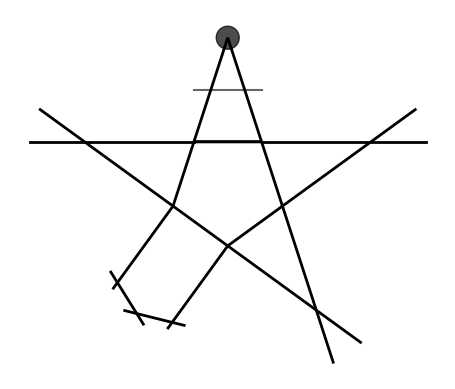

NAME               :: STAR_24
bracelet           :: (0, 0, 3, 0, 5)
t0_c3_tri_c5_pen   :: 3
t1_c4_tri_c5_pen   :: 1
t0_c5_pen_c5_pen   :: 1
Q_9_9              :: 1
mysterycell        :: 1


In [5]:
inspect(24)